In [22]:
import numpy as np
import pandas as pd
import random as random
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

x, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

df = pd.DataFrame(x, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
print(df.head())

(100, 6)
       col1      col2      col3      col4      col5  target
0  1.614826 -0.458738  0.616542 -1.631665 -1.230346       0
1  1.861072 -1.508245 -0.155899  0.891377 -2.739308       1
2 -2.539637 -2.828270  0.724470 -3.217737 -1.113939       0
3  0.518702  0.306150  1.177999 -1.710330 -1.751141       0
4  2.125746  0.322719  1.160419  1.361491 -0.400256       1


In [65]:
#function for raw sampling
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)

#function for feature sampling
def sample_featured(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1] - 1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

#function for combined sampling
def combined_sampling(df, percent):
    new_df = sample_rows(df, percent)
    return sample_featured(new_df, percent)

In [66]:
# df1 = sample_rows(df, 0.1)

# df2 = sample_rows(df, 0.1)

# df3 = sample_rows(df, 0.1)

df1 = sample_featured(df, 0.8)
df2 = sample_featured(df, 0.8)
df3 = sample_featured(df, 0.8)

/tmp/ipython-input-2250/3310651750.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-2250/3310651750.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
/tmp/ipython-input-2250/3310651750.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

In [67]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier()
model2 = DecisionTreeClassifier()
model3 = DecisionTreeClassifier()

model1.fit(df1.iloc[:, 0:4], df1.iloc[:, -1])


DecisionTreeClassifier()

In [68]:
model2.fit(df2.iloc[:, 0:4], df2.iloc[:, -1])

DecisionTreeClassifier()

In [69]:

model3.fit(df3.iloc[:, 0:4], df3.iloc[:, -1])

DecisionTreeClassifier()

In [70]:
from sklearn.tree import plot_tree


[Text(0.7142857142857143, 0.9545454545454546, 'x[3] <= 0.314\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.5, 0.8636363636363636, 'x[0] <= -0.898\ngini = 0.498\nsamples = 86\nvalue = [46.0, 40.0]'),
 Text(0.6071428571428572, 0.9090909090909092, 'True  '),
 Text(0.4642857142857143, 0.7727272727272727, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.5357142857142857, 0.7727272727272727, 'x[3] <= -1.115\ngini = 0.489\nsamples = 80\nvalue = [46, 34]'),
 Text(0.2857142857142857, 0.6818181818181818, 'x[1] <= -3.124\ngini = 0.497\nsamples = 48\nvalue = [22, 26]'),
 Text(0.25, 0.5909090909090909, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.32142857142857145, 0.5909090909090909, 'x[2] <= 0.178\ngini = 0.472\nsamples = 42\nvalue = [16, 26]'),
 Text(0.17857142857142858, 0.5, 'x[1] <= -1.493\ngini = 0.49\nsamples = 21\nvalue = [12, 9]'),
 Text(0.10714285714285714, 0.4090909090909091, 'x[3] <= -2.527\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.07142857142857142, 0.31

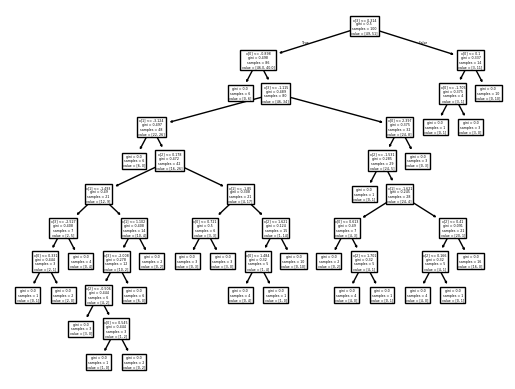

In [71]:
plot_tree(model1)

[Text(0.4166666666666667, 0.95, 'x[0] <= -0.561\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.1111111111111111, 0.85, 'x[1] <= 1.631\ngini = 0.188\nsamples = 38\nvalue = [34, 4]'),
 Text(0.2638888888888889, 0.8999999999999999, 'True  '),
 Text(0.05555555555555555, 0.75, 'gini = 0.0\nsamples = 27\nvalue = [27, 0]'),
 Text(0.16666666666666666, 0.75, 'x[3] <= -2.544\ngini = 0.463\nsamples = 11\nvalue = [7, 4]'),
 Text(0.1111111111111111, 0.65, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.2222222222222222, 0.65, 'x[1] <= 1.847\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.16666666666666666, 0.55, 'x[1] <= 1.721\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.1111111111111111, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.45, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2777777777777778, 0.55, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7222222222222222, 0.85, 'x[1] <= 3.121\ngini = 0.367\nsamples = 62\nvalue = [1

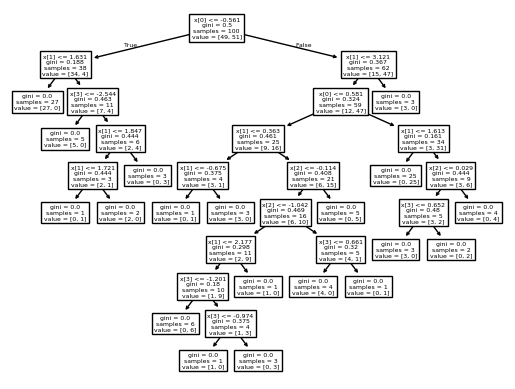

In [72]:
plot_tree(model2)

[Text(0.7142857142857143, 0.9545454545454546, 'x[3] <= 0.314\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.5, 0.8636363636363636, 'x[2] <= -0.898\ngini = 0.498\nsamples = 86\nvalue = [46.0, 40.0]'),
 Text(0.6071428571428572, 0.9090909090909092, 'True  '),
 Text(0.4642857142857143, 0.7727272727272727, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.5357142857142857, 0.7727272727272727, 'x[3] <= -1.115\ngini = 0.489\nsamples = 80\nvalue = [46, 34]'),
 Text(0.2857142857142857, 0.6818181818181818, 'x[0] <= -3.124\ngini = 0.497\nsamples = 48\nvalue = [22, 26]'),
 Text(0.25, 0.5909090909090909, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.32142857142857145, 0.5909090909090909, 'x[1] <= 0.178\ngini = 0.472\nsamples = 42\nvalue = [16, 26]'),
 Text(0.17857142857142858, 0.5, 'x[0] <= -1.493\ngini = 0.49\nsamples = 21\nvalue = [12, 9]'),
 Text(0.10714285714285714, 0.4090909090909091, 'x[3] <= -2.527\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.07142857142857142, 0.31

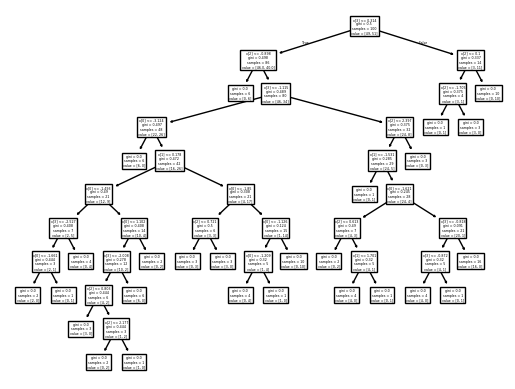

In [73]:
plot_tree(model3)

In [76]:
model1.predict(np.array([-1.654180,	-0.025546,	-0.325503,	-4.560948]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [77]:
model2.predict(np.array([-1.654180, -0.025546,	-0.325503,	-4.560948]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [78]:
model3.predict(np.array([-1.654180,	-0.025546,	-0.325503,	-4.560948]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

,col5,col1,col3,col2,target
0,-1.230346,1.614826,0.616542,-0.458738,0
1,-2.739308,1.861072,-0.155899,-1.508245,1
2,-1.113939,-2.539637,0.724470,-2.828270,0
3,-1.751141,0.518702,1.177999,0.306150,0
4,-0.400256,2.125746,1.160419,0.322719,1
...,...,...,...,...,...
95,-1.122079,0.477917,0.266144,-0.782002,0
96,-1.579463,3.343861,0.891511,-0.904569,0
97,-1.654180,-0.025546,-0.325503,-4.560948,1
98,1.049390,2.325868,-0.691891,0.425826,0
